## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Data

In [2]:
df = pd.read_csv(r"..\data\raw\Data_Entry_2017.csv")

## Inspection

In [3]:
df.head(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
5,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168,0.168,NaN
6,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,0.168,0.168,NaN
7,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143,NaN
8,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,0.168,0.168,NaN
9,00000003_005.png,Hernia,5,3,78,F,PA,2686,2991,0.143,0.143,NaN


In [4]:
df.shape

(112120, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  str    
 1   Finding Labels               112120 non-null  str    
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  str    
 6   View Position                112120 non-null  str    
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), str(4)
memory usage: 10.3 MB


In [6]:
df.describe(include="all")

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120,112120,112120.000000,112120.000000,112120.000000,112120,112120,112120.000000,112120.000000,112120.000000,112120.000000,0.0
unique,112120,836,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN
top,00000001_000.png,No Finding,NaN,NaN,NaN,M,PA,NaN,NaN,NaN,NaN,NaN
freq,1,60361,NaN,NaN,NaN,63340,67310,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,8.573751,14346.381743,46.901463,NaN,NaN,2646.078844,2486.438842,0.155649,0.155649,NaN
std,NaN,NaN,15.406320,8403.876972,16.839923,NaN,NaN,341.246429,401.268227,0.016174,0.016174,NaN
min,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,1143.000000,966.000000,0.115000,0.115000,NaN
25%,NaN,NaN,0.000000,7310.750000,35.000000,NaN,NaN,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,NaN,NaN,3.000000,13993.000000,49.000000,NaN,NaN,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,NaN,NaN,10.000000,20673.000000,59.000000,NaN,NaN,2992.000000,2991.000000,0.168000,0.168000,NaN


In [7]:
df.isnull().sum()

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

In [8]:
df.drop('Unnamed: 11', inplace=True, axis=1)

## Rename Columns

In [9]:
df = df.rename(columns={
    "Image Index": "image_id",
    "Finding Labels": "finding_labels",
    "Follow-up #": "follow_up",
    "Patient ID": "patient_id",
    "Patient Age": "patient_age",
    "Patient Gender": "patient_gender",
    "View Position": "view_position",
    "OriginalImage[Width": "image_width",
    "Height]": "image_height",
    "OriginalImagePixelSpacing[x": "pixel_spacing_x",
    "y]": "pixel_spacing_y"
})

In [10]:
df.columns

Index(['image_id', 'finding_labels', 'follow_up', 'patient_id', 'patient_age',
       'patient_gender', 'view_position', 'image_width', 'image_height',
       'pixel_spacing_x', 'pixel_spacing_y'],
      dtype='str')

## Check Duplicates

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["patient_id"].nunique()

30805

In [13]:
df["image_id"].duplicated().sum()

np.int64(0)

In [14]:
df["image_id"].nunique()

112120

## Age Cleaning

In [15]:
((df["patient_age"] < 0) | (df["patient_age"] > 100)).sum()

np.int64(16)

In [16]:
df = df[(df["patient_age"] >= 0) & (df["patient_age"] <= 100)]

In [17]:
((df["patient_age"] < 0) | (df["patient_age"] > 100)).sum()

np.int64(0)

In [18]:
df["patient_age"] = df["patient_age"].astype(int)

print(df["patient_age"].dtype)

int64


## Gender

In [19]:
df["patient_gender"].value_counts(dropna=False)

patient_gender
M    63328
F    48776
Name: count, dtype: int64

## View Position

In [20]:
df["view_position"].value_counts(dropna=False)

view_position
PA    67299
AP    44805
Name: count, dtype: int64

## Follow-up

In [21]:
df = df.drop(
    df[(df["follow_up"] > 70) & (df["finding_labels"] == "No Finding")].index
)

In [22]:
df["follow_up"].describe()

count    111698.000000
mean          8.252762
std          14.404566
min           0.000000
25%           0.000000
50%           3.000000
75%           9.000000
max         183.000000
Name: follow_up, dtype: float64

In [23]:
df["follow_up"].value_counts().sort_index().head(20)

follow_up
0     30797
1     13301
2      9186
3      7088
4      5759
5      4821
6      4034
7      3426
8      2932
9      2545
10     2224
11     1944
12     1709
13     1544
14     1363
15     1242
16     1122
17     1031
18      954
19      877
Name: count, dtype: int64

## finding label Column

In [24]:
labels = df["finding_labels"].str.split("|").explode()

labels.value_counts()

finding_labels
No Finding            59947
Infiltration          19891
Effusion              13316
Atelectasis           11558
Nodule                 6331
Mass                   5779
Pneumothorax           5301
Consolidation          4667
Pleural_Thickening     3384
Cardiomegaly           2776
Emphysema              2516
Edema                  2302
Fibrosis               1686
Pneumonia              1430
Hernia                  227
Name: count, dtype: int64

## make new balanced DataFrame

In [25]:
no_finding = df[df["finding_labels"] == "No Finding"].copy()

positive = df[df["finding_labels"] != "No Finding"].copy()

print("No Finding:", len(no_finding))
print("Positive cases:", len(positive))

No Finding: 59947
Positive cases: 51751


In [26]:
NO_FINDING_LIMIT = 30000

no_finding_sampled = no_finding.sample(
    n=min(NO_FINDING_LIMIT, len(no_finding)),
    random_state=42
)

df_balanced = pd.concat(
    [positive, no_finding_sampled],
    ignore_index=True
)

df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Original:", len(df))
print("Balanced:", len(df_balanced))

Original: 111698
Balanced: 81751


In [27]:
conditions = {
    "Infiltration",
    "Effusion",
    "Atelectasis"
}

df_balanced = df_balanced[
    (df_balanced["finding_labels"] == "No Finding") |
    (
        df_balanced["finding_labels"]
        .str.split("|")
        .apply(lambda x: set(x).issubset(conditions))
    )
]

In [28]:
df_balanced

,image_id,finding_labels,follow_up,patient_id,patient_age,patient_gender,view_position,image_width,image_height,pixel_spacing_x,pixel_spacing_y
0,00003823_000.png,No Finding,0,3823,66,F,PA,2048,2500,0.171,0.171
1,00004381_035.png,Infiltration,35,4381,25,M,PA,2992,2991,0.143,0.143
2,00011884_001.png,No Finding,1,11884,24,M,AP,3056,2544,0.139,0.139
3,00024887_000.png,No Finding,0,24887,36,M,PA,2992,2991,0.143,0.143
5,00013208_000.png,No Finding,0,13208,60,M,PA,2992,2991,0.143,0.143
...,...,...,...,...,...,...,...,...,...,...,...
81743,00007008_001.png,No Finding,1,7008,29,M,AP,2500,2048,0.171,0.171
81744,00025498_001.png,Infiltration,1,25498,86,M,AP,3056,2544,0.139,0.139
81747,00000042_004.png,No Finding,4,42,71,M,AP,2808,2544,0.139,0.139
81748,00012716_000.png,No Finding,0,12716,40,M,PA,2986,2991,0.143,0.143


In [29]:
df_balanced.groupby("patient_id")["follow_up"].max().describe()

count    20080.000000
mean         3.393227
std          8.344973
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        183.000000
Name: follow_up, dtype: float64

## Categorical Features

In [30]:
df_balanced["patient_gender"] = df_balanced["patient_gender"].astype("category")
df_balanced["view_position"] = df_balanced["view_position"].astype("category")

## Finding Labels

In [31]:
df_balanced["finding_labels"].value_counts()

finding_labels
No Finding                           30000
Infiltration                          9546
Atelectasis                           4214
Effusion                              3955
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Atelectasis|Effusion                  1165
Atelectasis|Effusion|Infiltration      737
Effusion|Atelectasis                     2
Effusion|Infiltration|Atelectasis        2
Infiltration|Effusion                    1
Name: count, dtype: int64

## sorting 

In [32]:
df_balanced["finding_labels"] = df_balanced["finding_labels"].apply(
    lambda x: sorted(x.split("|"))
)

## Image Metadata Sanity Check

In [33]:
invalid_dimensions = df_balanced[
    (df_balanced["image_width"] <= 0) | 
    (df_balanced["image_height"] <= 0) | 
    (df_balanced["pixel_spacing_x"] <= 0) | 
    (df_balanced["pixel_spacing_y"] <= 0)
]

len(invalid_dimensions)

0

In [34]:
(
    df_balanced["pixel_spacing_x"] ==
    df_balanced["pixel_spacing_y"]
).value_counts()

True    52575
Name: count, dtype: int64

## EDA (Exploratory Data Analysis)

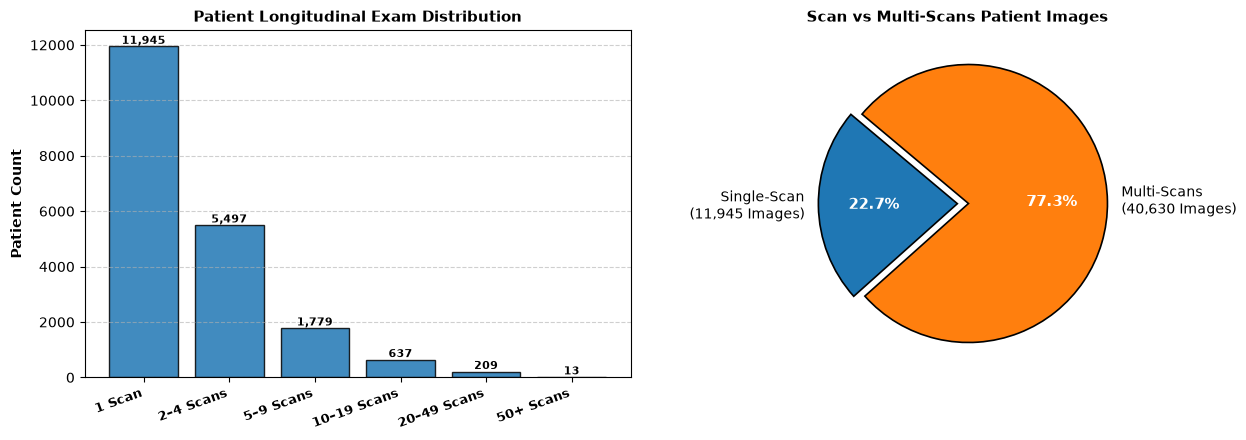

In [35]:
patient_scan_counts = df_balanced["patient_id"].value_counts()

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))


# =========================
# 1. Patient Exam Distribution
# =========================

scan_bins = [1, 2, 5, 10, 20, 50, 200]

scan_binned = (
    pd.cut(
        patient_scan_counts,
        bins=scan_bins,
        right=False
    )
    .value_counts()
    .sort_index()
)

labels = [
    "1 Scan",
    "2–4 Scans",
    "5–9 Scans",
    "10–19 Scans",
    "20–49 Scans",
    "50+ Scans"
]

bars = ax1.bar(
    labels,
    scan_binned.values,
    edgecolor="black",
    alpha=0.85
)

ax1.set_title(
    "Patient Longitudinal Exam Distribution",
    fontsize=11,
    fontweight="bold"
)

ax1.set_ylabel(
    "Patient Count",
    fontsize=10,
    fontweight="bold"
)

ax1.set_xticks(range(len(labels)))

ax1.set_xticklabels(
    labels,
    rotation=20,
    ha="right",
    fontsize=9,
    fontweight="bold"
)

for bar in bars:

    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

# =========================
# 2. Scan vs Multi-Scans Images
# =========================

single_imgs = (
    df_balanced["patient_id"]
    .map(patient_scan_counts)
    .eq(1)
    .sum()
)

repeat_imgs = (
    df_balanced["patient_id"]
    .map(patient_scan_counts)
    .gt(1)
    .sum()
)

wedges, texts, autotexts = ax2.pie(
    [single_imgs, repeat_imgs],

    labels=[
        f"Single-Scan\n({single_imgs:,} Images)",
        f"Multi-Scans\n({repeat_imgs:,} Images)"
    ],

    autopct="%1.1f%%",

    startangle=140,

    explode=(0, 0.08),

    wedgeprops={
        "edgecolor": "black",
        "linewidth": 1.2
    }
)

for text in autotexts:

    text.set_color("white")
    text.set_fontweight("bold")
    text.set_fontsize(10.5)


ax2.set_title(
    "Scan vs Multi-Scans Patient Images",
    fontsize=11,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

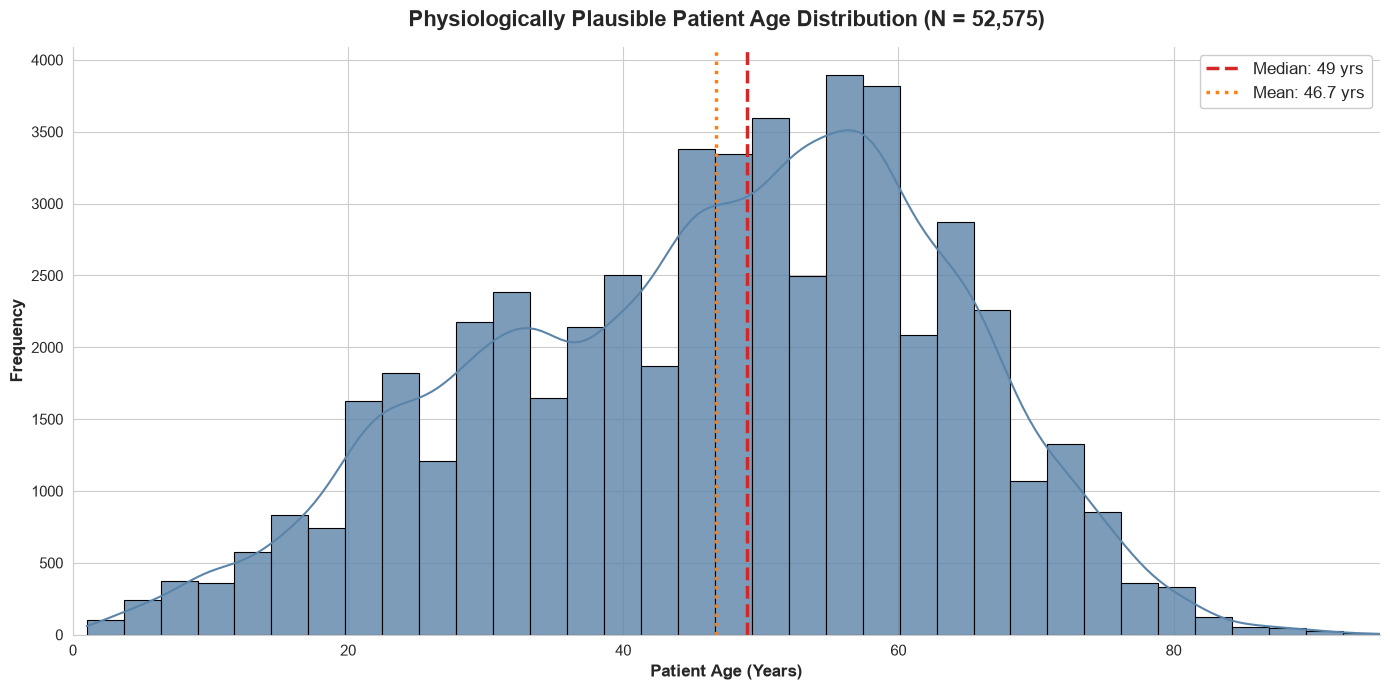

In [36]:
mean_age = df_balanced['patient_age'].mean()
median_age = df_balanced['patient_age'].median()
total_count = len(df_balanced)

plt.figure(figsize=(14, 7)) 
sns.set_style("whitegrid") 


sns.histplot(data=df_balanced, x='patient_age', bins=35, kde=True, 
             color='#5b84a9', edgecolor='black', alpha=0.8, linewidth=0.8)


plt.axvline(median_age, color='#d62728', linestyle='--', linewidth=2.5, 
            label=f'Median: {median_age:.0f} yrs')


plt.axvline(mean_age, color='#ff7f0e', linestyle=':', linewidth=2.5, 
            label=f'Mean: {mean_age:.1f} yrs')


plt.title(f'Physiologically Plausible Patient Age Distribution (N = {total_count:,})', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Patient Age (Years)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')


plt.xlim(0, 95)
plt.legend(fontsize=12, loc='upper right', frameon=True, facecolor='white', framealpha=1)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)


sns.despine(left=False, bottom=False)


plt.tight_layout()
plt.show()

### Age Distribution in balanced data

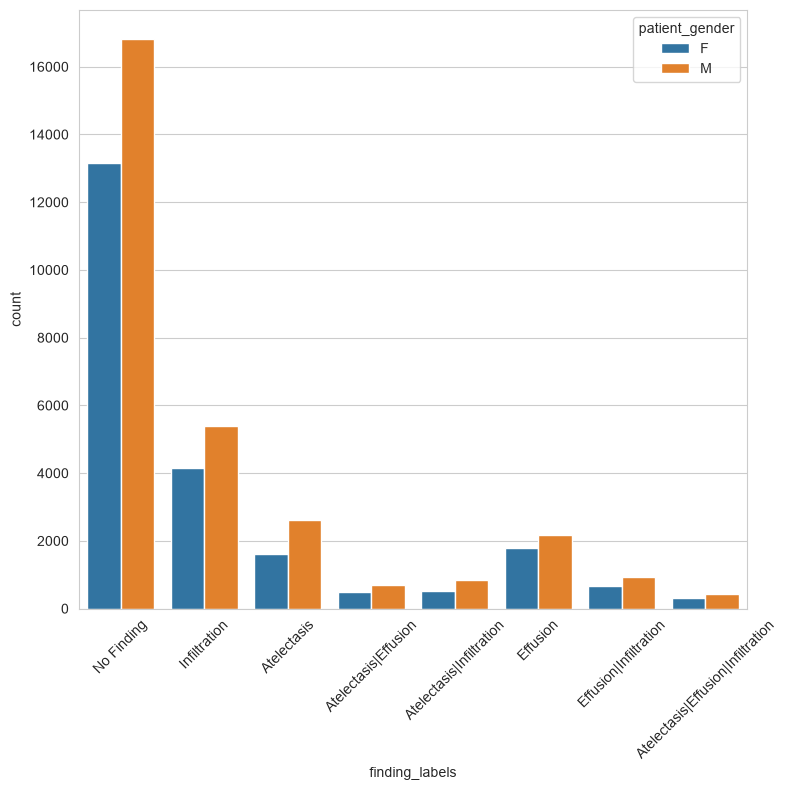

In [37]:
plot_df = df_balanced.copy()

plot_df["finding_labels"] = plot_df["finding_labels"].apply(
    lambda x: "|".join(x)
)

plt.figure(figsize=(8, 8))

sns.countplot(
    data=plot_df,
    x="finding_labels",
    hue="patient_gender"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### view Gender in each finding_labels

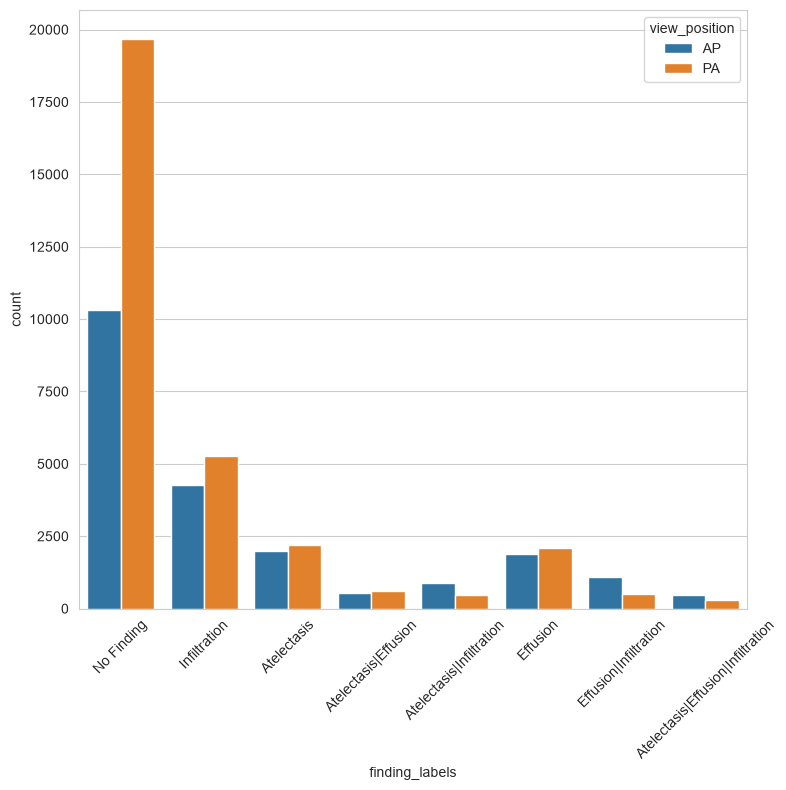

In [38]:
plot_df = df_balanced.copy()

plot_df["finding_labels"] = plot_df["finding_labels"].apply(
    lambda x: "|".join(x)
)

plt.figure(figsize=(8, 8))

sns.countplot(
    data=plot_df,
    x="finding_labels",
    hue="view_position"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### view posion in each finding_labels

In [39]:
quality_report = pd.DataFrame({
    "metric": [
        "Number of rows",
        "Number of columns",
        "Unique images",
        "Unique patients",
        "Missing values",
        "Invalid ages",
        "Unique findings",
        "PA images",
        "AP images"
    ],
    "value": [
        len(df_balanced),
        df_balanced.shape[1],
        df_balanced["image_id"].nunique(),
        df_balanced["patient_id"].nunique(),
        df_balanced.isnull().sum().sum(),
        (
            (df_balanced["patient_age"] < 0) |
            (df_balanced["patient_age"] > 100)
        ).sum(),
        df_balanced["finding_labels"].explode().nunique(),
        (df_balanced["view_position"] == "PA").sum(),
        (df_balanced["view_position"] == "AP").sum()
    ]
})

quality_report

,metric,value
0,Number of rows,52575
1,Number of columns,11
2,Unique images,52575
3,Unique patients,20080
4,Missing values,0
5,Invalid ages,0
6,Unique findings,4
7,PA images,31149
8,AP images,21426


## Export Cleaned Data

In [40]:
df_balanced.reset_index(drop=True, inplace=True)

print(df_balanced.info())
df_balanced.head()

<class 'pandas.DataFrame'>
RangeIndex: 52575 entries, 0 to 52574
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   image_id         52575 non-null  str     
 1   finding_labels   52575 non-null  object  
 2   follow_up        52575 non-null  int64   
 3   patient_id       52575 non-null  int64   
 4   patient_age      52575 non-null  int64   
 5   patient_gender   52575 non-null  category
 6   view_position    52575 non-null  category
 7   image_width      52575 non-null  int64   
 8   image_height     52575 non-null  int64   
 9   pixel_spacing_x  52575 non-null  float64 
 10  pixel_spacing_y  52575 non-null  float64 
dtypes: category(2), float64(2), int64(5), object(1), str(1)
memory usage: 3.7+ MB
None


,image_id,finding_labels,follow_up,patient_id,patient_age,patient_gender,view_position,image_width,image_height,pixel_spacing_x,pixel_spacing_y
0,00003823_000.png,[No Finding],0,3823,66,F,PA,2048,2500,0.171,0.171
1,00004381_035.png,[Infiltration],35,4381,25,M,PA,2992,2991,0.143,0.143
2,00011884_001.png,[No Finding],1,11884,24,M,AP,3056,2544,0.139,0.139
3,00024887_000.png,[No Finding],0,24887,36,M,PA,2992,2991,0.143,0.143
4,00013208_000.png,[No Finding],0,13208,60,M,PA,2992,2991,0.143,0.143


In [41]:
df_balanced.to_csv(r"..\data\processed\Data_Entry_2017_Cleaned.csv", index=False)